Dataset created successfully!
Total complaints: 56


,complaint,category
0,I was charged twice for the same order,Billing
1,There is an incorrect amount on my bill,Billing
2,My credit card was charged extra,Billing
3,The invoice contains a wrong charge,Billing
4,I was billed more than the actual price,Billing
5,Why was I charged an additional amount,Billing
6,My monthly bill is incorrect,Billing
7,I see an unauthorized charge on my bill,Billing
8,My order has not been delivered yet,Delivery
9,The delivery is very late,Delivery



Training samples: 44
Testing samples: 12

Model training completed!

MODEL PERFORMANCE
Accuracy: 91.67%

Classification Report:
              precision    recall  f1-score   support

     Account       1.00      1.00      1.00         1
     Billing       1.00      1.00      1.00         1
    Delivery       1.00      1.00      1.00         2
     Product       1.00      1.00      1.00         2
      Refund       1.00      0.50      0.67         2
     Service       1.00      1.00      1.00         2
   Technical       0.67      1.00      0.80         2

    accuracy                           0.92        12
   macro avg       0.95      0.93      0.92        12
weighted avg       0.94      0.92      0.91        12



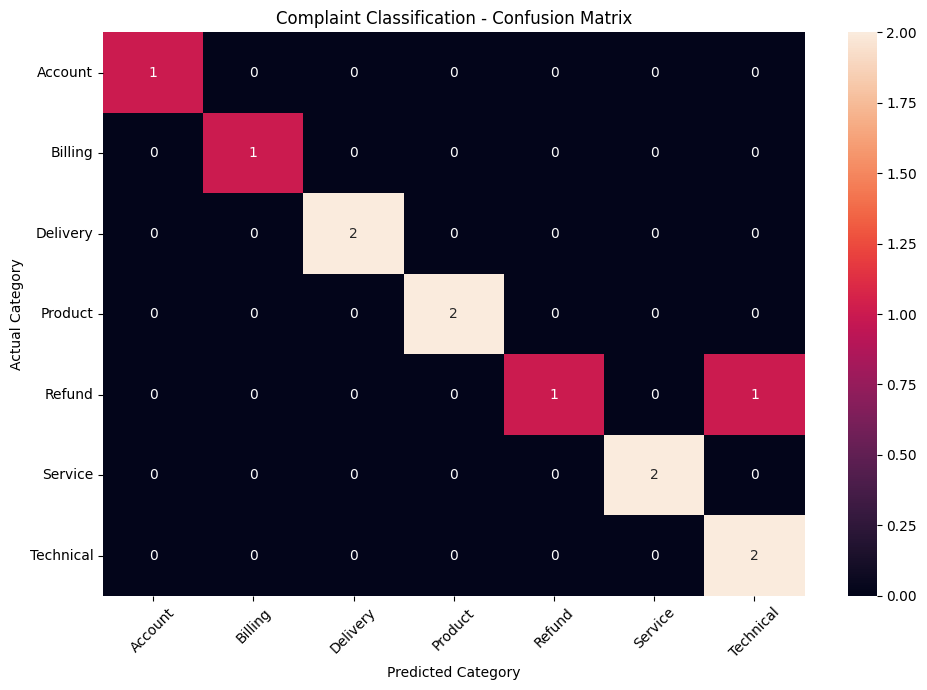

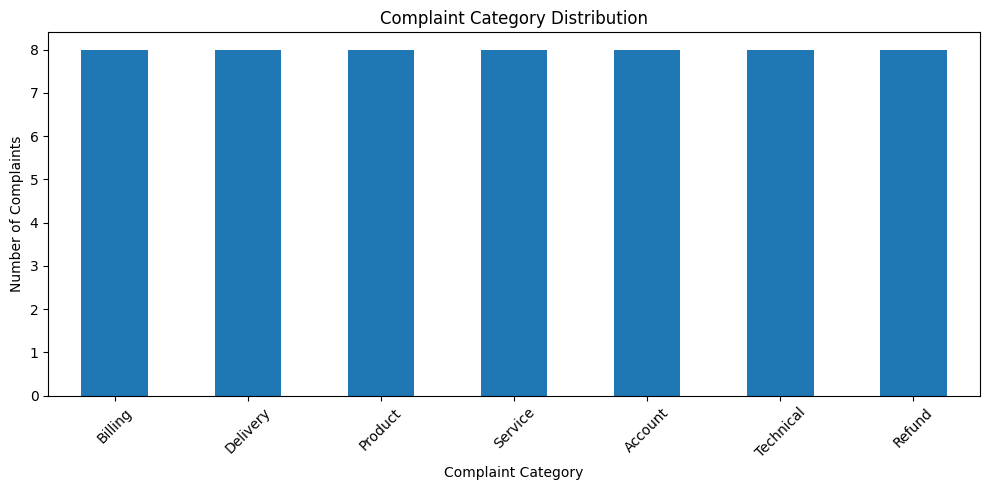


TEST COMPLAINT PREDICTIONS

Complaint: My package has not arrived and the delivery is very late
Category : Delivery
Confidence: 36.10%
Priority : MEDIUM

Complaint: I was charged twice for the same purchase
Category : Billing
Confidence: 33.03%
Priority : LOW

Complaint: The mobile application keeps crashing
Category : Technical
Confidence: 19.63%
Priority : LOW

Complaint: I want my refund immediately
Category : Refund
Confidence: 32.32%
Priority : HIGH

Complaint: I cannot login to my account
Category : Account
Confidence: 39.23%
Priority : LOW

Complaint: The product I received is broken
Category : Product
Confidence: 35.00%
Priority : LOW

AI COMPLAINT CLASSIFIER

Enter your complaint (type 'exit' to stop): My payment was charged twice and this is very urgent

--------------------------------------
AI ANALYSIS
--------------------------------------
Complaint : My payment was charged twice and this is very urgent
Category  : Billing
Confidence: 29.22%
Priority  : HIGH
Action    : I

In [ ]:
# ============================================================
# AI COMPLAINT CLASSIFICATION SYSTEM
# TSA SUBJECT PROJECT
# ============================================================

# Install required libraries
!pip -q install scikit-learn pandas matplotlib seaborn

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 2. CREATE COMPLAINT DATASET
# ============================================================

data = {
    "complaint": [
        # Billing
        "I was charged twice for the same order",
        "There is an incorrect amount on my bill",
        "My credit card was charged extra",
        "The invoice contains a wrong charge",
        "I was billed more than the actual price",
        "Why was I charged an additional amount",
        "My monthly bill is incorrect",
        "I see an unauthorized charge on my bill",

        # Delivery
        "My order has not been delivered yet",
        "The delivery is very late",
        "My package has not arrived",
        "The delivery date has passed",
        "Where is my order",
        "My parcel is delayed",
        "The courier has not delivered my package",
        "I have been waiting for my delivery",

        # Product
        "The product I received is damaged",
        "The item is defective",
        "The product stopped working after one day",
        "I received a broken product",
        "The product quality is very poor",
        "The item I received is damaged",
        "The product does not work properly",
        "I received the wrong product",

        # Service
        "The customer service was very poor",
        "Nobody responded to my complaint",
        "The support team was rude",
        "I am unhappy with the service",
        "The staff did not help me",
        "Customer support was not helpful",
        "I had a bad experience with your service",
        "The service quality is disappointing",

        # Account
        "I cannot login to my account",
        "My account has been locked",
        "I forgot my account password",
        "I cannot access my profile",
        "My account information is incorrect",
        "I am unable to sign in",
        "My account is not working",
        "Please help me recover my account",

        # Technical
        "The application keeps crashing",
        "The website is not working",
        "The app shows an error",
        "I cannot upload my document",
        "The website is very slow",
        "The application has a technical problem",
        "The payment page is not loading",
        "I am getting an error message",

        # Refund
        "I have not received my refund",
        "Please process my refund",
        "My refund is delayed",
        "When will I get my money back",
        "I want a refund for my order",
        "The refunded amount has not arrived",
        "I requested a refund several days ago",
        "Please return my payment"
    ],

    "category": (
        ["Billing"] * 8 +
        ["Delivery"] * 8 +
        ["Product"] * 8 +
        ["Service"] * 8 +
        ["Account"] * 8 +
        ["Technical"] * 8 +
        ["Refund"] * 8
    )
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Total complaints:", len(df))

display(df.head(10))

# ============================================================
# 3. TEXT PREPROCESSING
# ============================================================

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_complaint"] = df["complaint"].apply(clean_text)

# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X = df["clean_complaint"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ============================================================
# 5. TF-IDF + LOGISTIC REGRESSION MODEL
# ============================================================

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            stop_words="english",
            max_features=5000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000
        )
    )
])

# Train model
model.fit(X_train, y_train)

print("\nModel training completed!")

# ============================================================
# 6. MODEL EVALUATION
# ============================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Complaint Classification - Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================
# 8. CATEGORY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

df["category"].value_counts().plot(
    kind="bar"
)

plt.title("Complaint Category Distribution")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 9. PRIORITY DETECTION
# ============================================================

def detect_priority(text):

    text_lower = text.lower()

    high_words = [
        "urgent",
        "emergency",
        "immediately",
        "fraud",
        "stolen",
        "unauthorized",
        "critical",
        "danger",
        "serious"
    ]

    medium_words = [
        "very late",
        "not working",
        "damaged",
        "wrong",
        "problem",
        "issue",
        "delay",
        "error"
    ]

    if any(word in text_lower for word in high_words):
        return "HIGH"

    elif any(word in text_lower for word in medium_words):
        return "MEDIUM"

    else:
        return "LOW"

# ============================================================
# 10. COMPLAINT PREDICTION FUNCTION
# ============================================================

def classify_complaint(complaint):

    cleaned = clean_text(complaint)

    prediction = model.predict([cleaned])[0]

    probabilities = model.predict_proba([cleaned])[0]

    confidence = max(probabilities) * 100

    priority = detect_priority(complaint)

    return prediction, confidence, priority

# ============================================================
# 11. TEST COMPLAINTS
# ============================================================

test_complaints = [
    "My package has not arrived and the delivery is very late",
    "I was charged twice for the same purchase",
    "The mobile application keeps crashing",
    "I want my refund immediately",
    "I cannot login to my account",
    "The product I received is broken"
]

print("\n======================================")
print("TEST COMPLAINT PREDICTIONS")
print("======================================")

for complaint in test_complaints:

    category, confidence, priority = classify_complaint(
        complaint
    )

    print("\nComplaint:", complaint)
    print("Category :", category)
    print(f"Confidence: {confidence:.2f}%")
    print("Priority :", priority)

# ============================================================
# 12. INTERACTIVE COMPLAINT CLASSIFIER
# ============================================================

print("\n======================================")
print("AI COMPLAINT CLASSIFIER")
print("======================================")

while True:

    complaint = input(
        "\nEnter your complaint (type 'exit' to stop): "
    )

    if complaint.lower() == "exit":
        print("\nThank you for using AI Complaint Classification System!")
        break

    if complaint.strip() == "":
        print("Please enter a complaint.")
        continue

    category, confidence, priority = classify_complaint(
        complaint
    )

    print("\n--------------------------------------")
    print("AI ANALYSIS")
    print("--------------------------------------")

    print("Complaint :", complaint)
    print("Category  :", category)
    print(f"Confidence: {confidence:.2f}%")
    print("Priority  :", priority)

    if priority == "HIGH":
        print("Action    : Immediate attention required")

    elif priority == "MEDIUM":
        print("Action    : Resolve as soon as possible")

    else:
        print("Action    : Normal support queue")